reconocer la hora 


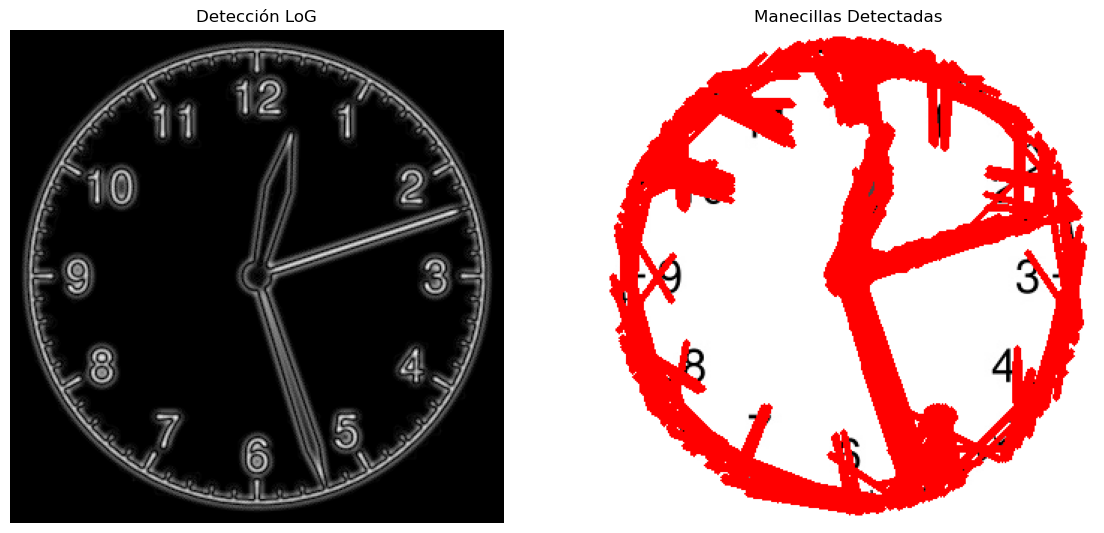

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

ruta = r'D:\UNIVALLE\PDY\unidad 1\clases\img\reloj1.jpeg'
img = cv2.imread(ruta, 0)

if img is not None:
    # 1. Aplicar LoG (tu código actual)
    img_blur = cv2.GaussianBlur(img, (9, 9), 0)
    laplacian = cv2.Laplacian(img_blur, cv2.CV_64F)
    log_result = np.uint8(np.absolute(laplacian))

    # 2. Transformada de Hough sobre la salida del LoG
    # El LoG ya resalta los bordes, así que Hough funcionará mejor
    lines = cv2.HoughLinesP(log_result, 1, np.pi/180, threshold=30, 
                            minLineLength=50, maxLineGap=10)

    # 3. Dibujar resultados
    # Convertimos a color para dibujar líneas de colores
    img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(img_color, (x1, y1), (x2, y2), (0, 0, 255), 3)

    # 4. Mostrar ambos
    plt.figure(figsize=(14, 7))
    plt.subplot(1, 2, 1)
    plt.imshow(log_result, cmap='gray')
    plt.title('Detección LoG')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
    plt.title('Manecillas Detectadas')
    plt.axis('off')
    plt.show()
else:
    print("Error: Revisa la ruta.")

deteccion de las manesillas

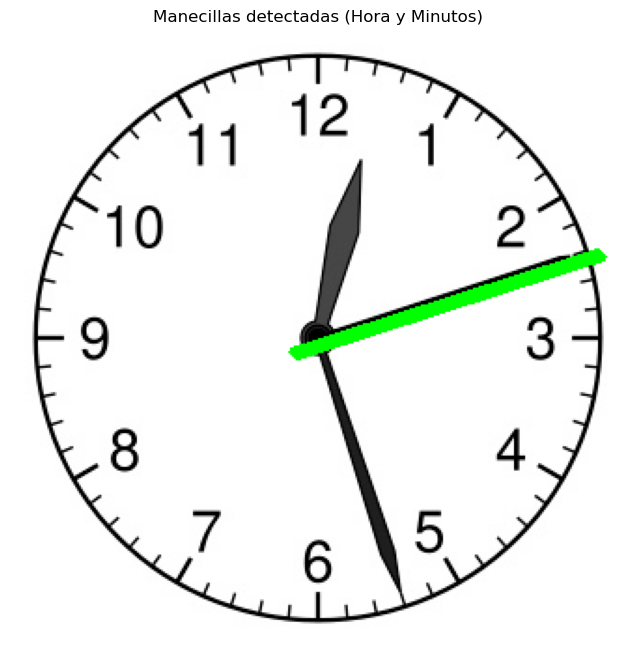

In [3]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

ruta = r'D:\UNIVALLE\PDY\unidad 1\clases\img\reloj1.jpeg'
img = cv2.imread(ruta)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 1. Aplicar LoG para obtener bordes claros
img_blur = cv2.GaussianBlur(gray, (9, 9), 0)
laplacian = cv2.Laplacian(img_blur, cv2.CV_64F)
log_result = np.uint8(np.absolute(laplacian))

# 2. Detectar líneas con Hough
lines = cv2.HoughLinesP(log_result, 1, np.pi/180, threshold=40, 
                        minLineLength=80, maxLineGap=10)

# 3. Filtrar para quedarnos solo con las dos líneas más largas (las manecillas)
if lines is not None:
    # Calcular la longitud de cada línea detectada
    lineas_con_longitud = []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        longitud = np.sqrt((x2-x1)**2 + (y2-y1)**2)
        lineas_con_longitud.append((longitud, line[0]))
    
    # Ordenar por longitud de mayor a menor y tomar las 2 primeras
    lineas_con_longitud.sort(key=lambda x: x[0], reverse=True)
    manecillas = lineas_con_longitud[:2]

    # Dibujar solo las manecillas detectadas
    for _, linea in manecillas:
        x1, y1, x2, y2 = linea
        cv2.line(img, (x1, y1), (x2, y2), (0, 255, 0), 4)

# Visualización
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Manecillas detectadas (Hora y Minutos)')
plt.axis('off')
plt.show()

seleccionamos por grosor las manecillas

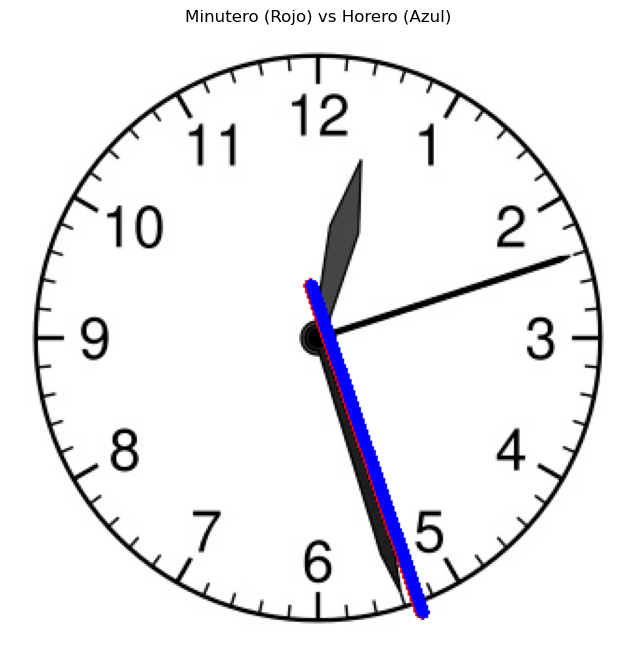

In [4]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# 1. Preparar imagen
ruta = r'D:\UNIVALLE\PDY\unidad 1\clases\img\reloj1.jpeg'
img = cv2.imread(ruta)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Preprocesamiento (LoG)
img_blur = cv2.GaussianBlur(gray, (9, 9), 0)
laplacian = cv2.Laplacian(img_blur, cv2.CV_64F)
log_result = np.uint8(np.absolute(laplacian))

# 3. Detectar todas las líneas posibles
lines = cv2.HoughLinesP(log_result, 1, np.pi/180, threshold=30, 
                        minLineLength=40, maxLineGap=10)

# 4. Clasificación: separar por longitud
if lines is not None:
    # Convertir a lista y calcular longitudes
    line_data = []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        length = np.sqrt((x2-x1)**2 + (y2-y1)**2)
        line_data.append({'coords': (x1, y1, x2, y2), 'length': length})
    
    # Ordenar por longitud de mayor a menor
    line_data.sort(key=lambda x: x['length'], reverse=True)
    
    # El minutero suele ser la más larga, el horero la segunda más larga
    minutero = line_data[0]
    horero = line_data[1] if len(line_data) > 1 else None
    
    # Dibujar resultados con colores diferentes
    # Minutero (Rojo), Horero (Azul)
    cv2.line(img, (minutero['coords'][0], minutero['coords'][1]), 
             (minutero['coords'][2], minutero['coords'][3]), (0, 0, 255), 5)
    
    if horero:
        cv2.line(img, (horero['coords'][0], horero['coords'][1]), 
                 (horero['coords'][2], horero['coords'][3]), (255, 0, 0), 5)

# Visualización
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Minutero (Rojo) vs Horero (Azul)')
plt.axis('off')
plt.show()

prueba 2 con el angulo de tiempo

error: OpenCV(4.12.0) C:\Users\dev-admin\buildout\croot\opencv-suite_1765297159650\work\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'
